# EXERCISE 1

## Libraries used:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### A. FORWARD DIFFERENCE

**Functions used**

In [2]:
def f_tan(x):
    return np.tan(x)

def d_f_tan(x):
    return 1 + np.tan(x)**2

def forward_diff(f, x, h):
    return (f(x + h) - f(x)) / h

**Information given:**

In [3]:
x = 1.0
epsilon_mach = np.finfo(float).eps
h_values = np.array([10**(-k) for k in range(17)])

**Below are the error calculations:**

In [4]:
# Computational values
forward_values = forward_diff(f_tan,x,h_values)

# To get the *computational* errors, we subtract the actual values from the computational values
forward_errors = np.abs(forward_values - d_f_tan(x))

# The maximum value of the 2nd derative of tan(x) for x = 1
M_2 = np.abs(2 * f_tan(x) * d_f_tan(x))

# Truncation forward error
t_forward_error = M_2 * h_values / 2
# Numerical (rounding) error
r_forward_error = 2 * epsilon_mach / h_values

**Presenting data on a chart**

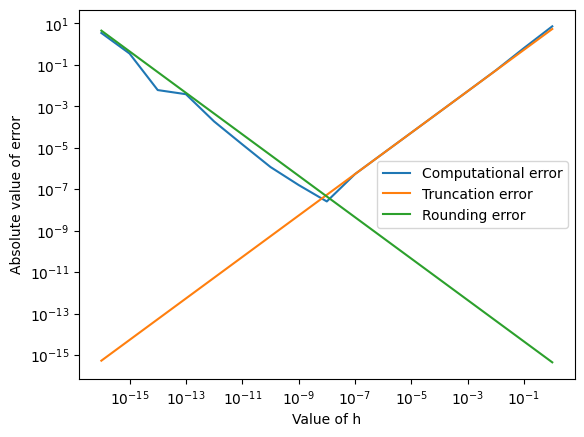

In [5]:
plt.xscale("log")
plt.yscale("log")
plt.plot(h_values, forward_errors, label = "Computational error") # 1st chart
plt.plot(h_values, t_forward_error, label = "Truncation error")   # 2nd chart
plt.plot(h_values, r_forward_error, label = "Rounding error")     # 3rd chart
plt.xlabel("Value of h")
plt.ylabel("Absolute value of error")
plt.legend()
plt.show()

**The point at which the computational error has the smallest value:**

In [6]:
h_min = 2 * np.sqrt(epsilon_mach/M_2)
print(h_min)

9.123695225180451e-09


**The absolute value of the relative error at the designated point (x = 1)**

In [7]:
h_value = np.array([h_min])

print(np.abs((forward_diff(f_tan, x, h_value) - d_f_tan(x)) / d_f_tan(x) ))

[5.33866349e-09]


## Computional min error

In [8]:
t_error_min_2 =  M_2 * h_min / 2

r_error_min_2 = 2 * epsilon_mach / h_min

E_h_min = t_error_min_2 + r_error_min_2
print(E_h_min)

9.734854110962026e-08


### B. CENTER DIFFERENCE

**Functions used**

In [9]:
def d_f_tan(x):
    return 1 + np.tan(x)**2
    
def central_diff(f, x, h):
    return (f(x + h) - f(x - h)) / (2 * h)

**Information given:**

In [10]:
x = 1.0
epsilon_mach = np.finfo(float).eps
h_values = np.array([10**(-k) for k in range(17)])

**Below are the error calculations:**

In [11]:
# Computational values
central_values = central_diff(f_tan,x,h_values)

# To get the *computational* errors, we subtract the actual values from the computational values
central_errors = np.abs(central_values - d_f_tan(x))

# The maximum value of the 3rd derative of tan(x) for x = 1
M_3 = np.abs(2 * (d_f_tan(x))**2 + 4 * f_tan(x)**2 * (d_f_tan(x)))

# Truncation central error
t_central_error = (M_3 * h_values**2) / 6

# Numerical (rounding) error
r_central_error = epsilon_mach / h_values

**Presenting data on a chart**

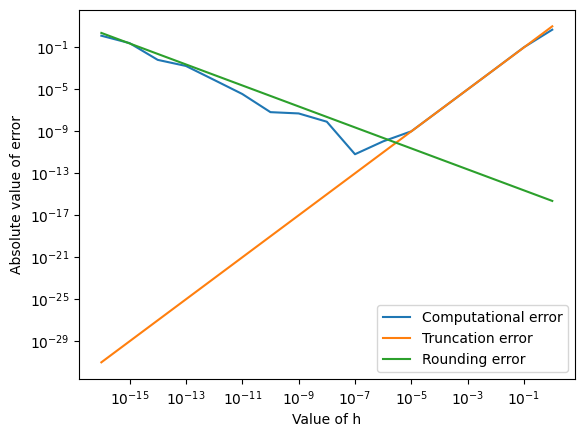

In [12]:
plt.xscale("log")
plt.yscale("log")
plt.plot(h_values, central_errors, label = "Computational error")
plt.plot(h_values, t_central_error, label = "Truncation error")
plt.plot(h_values, r_central_error, label = "Rounding error")
plt.xlabel("Value of h")
plt.ylabel("Absolute value of error")
plt.legend()
plt.show()

**The point at which the computational error has the smallest value:**

In [18]:
h_min_3 = np.cbrt(3 * epsilon_mach / M_3)
print(h_min_3)

2.2732741568390613e-06


**The absolute value of the relative error at the designated point (x = 1)**

In [19]:
h_value = np.array([h_min_3])
print(np.abs((central_diff(f_tan, x, h_value) - d_f_tan(x)) / d_f_tan(x) ))

[2.53349201e-11]


## Computational error

In [20]:
t_error_min_3 =  M_3 * ( h_min ** 2 )/6 
r_error_min_3 = epsilon_mach / h_min_3

E_h_min_3 = t_error_min_3 + r_error_min_3
print(E_h_min_3)

1.4651418368766806e-10
